# `scipy` & Differential Equations

A **differential equation** is an equation involving an unknown function and one or more of its derivatives. Differential equations describe **how quantities change over time or space.**

#### Ordinary Differential Equation (ODE)

Contains derivatives with respect to **one variable**. For example,

$$\frac{dy}{dt}=2y$$



#### Partial Differential Equation (PDE)

Contains partial derivatives with respect to multiple variables. For, example

$$\frac{\partial u}{\partial t}=\frac{\partial^2u}{\partial x^2}$$

Today we focus on **ordinary differential equations (ODEs).**


In [ ]:
# preliminaries

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


#### Growth Model

Suppose a population grows at a rate proportional to its current size.

$$\frac{dy}{dt}=0.5y$$
where
- $y(t)$ = population
- $t$ = time

Notice that the larger the population becomes, the faster it grows. Using calculus, the solution is

$$y(t)=Ce^{0.5t}$$

where $C$ is determined by the initial condition.


### Solving Numerically

Python can solve differential equations without requiring the analytical solution.


First, we define our differential equation:

In [12]:
def model(t,y):
    return 0.5*y

Next, we suppose we have some initial condition:

In [13]:
y0 = [10]

And we have some bounds to solve within, say $t=0$ to $t=10$:

In [4]:
t0 = 0
t1 = 10

In [20]:
solution = solve_ivp(
    model,
    [t0,t1],
    y0,
    dense_output=True
)

Now, Python has the solution:

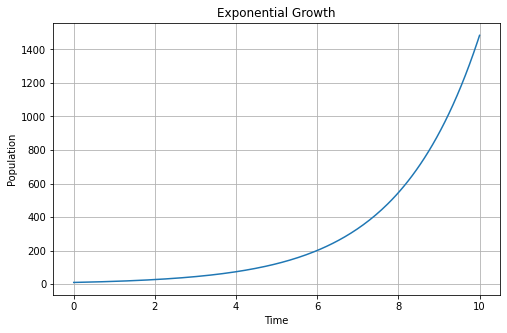

In [21]:
t = np.linspace(0,10,200)
y = solution.sol(t)[0]

plt.figure(figsize=(8,5))

plt.plot(t,y)

plt.xlabel("Time")
plt.ylabel("Population")

plt.title("Exponential Growth")

plt.grid()

plt.show()


## Exponential Decay

Many physical systems decrease over time (e.g. radioactive decay). We can model this by switching the sign:
$$\frac{dy}{dt}=-0.3y$$


In [22]:
def decay(t,y):
    return -0.3*y

solution = solve_ivp(
    decay,
    [0,15],
    [20],
    dense_output=True
)

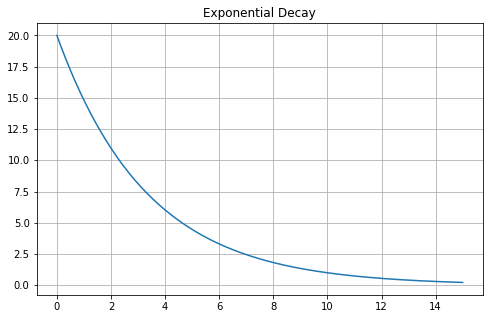

In [23]:
t = np.linspace(0,15,200)

plt.figure(figsize=(8,5))

plt.plot(t,
         solution.sol(t)[0])

plt.title("Exponential Decay")

plt.grid()

plt.show()



## Logistic Growth

Unlimited growth is unrealistic.

Instead, suppose

$$
\frac{dy}{dt}=ry\left(1-\frac{y}{K}\right)
$$

where

- $r$ = growth rate
- $K$ = carrying capacity


In [9]:
r = 0.6
K = 100

def logistic(t,y):

    return r*y*(1-y/K)

solution = solve_ivp(
    logistic,
    [0,30],
    [5],
    dense_output=True
)

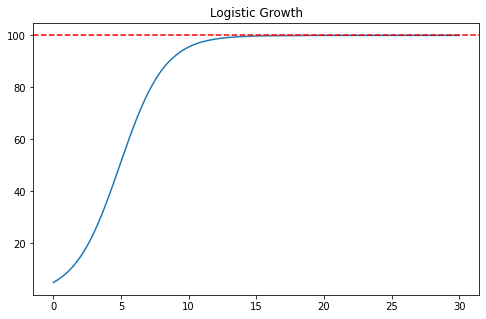

In [10]:
t = np.linspace(0,30,300)

plt.figure(figsize=(8,5))

plt.plot(t,
         solution.sol(t)[0])

plt.axhline(K,
            linestyle="--",
            color="red")

plt.title("Logistic Growth")

plt.show()

Notice that the population levels off at the carrying capacity.


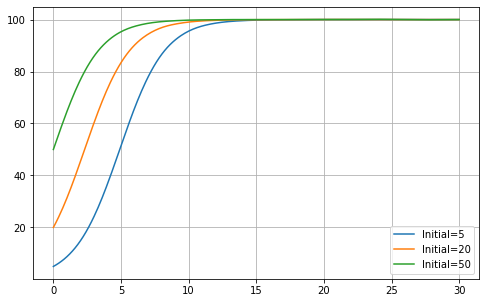

In [11]:
initials = [5,20,50]

plt.figure(figsize=(8,5))

for y0 in initials:

    solution = solve_ivp(
        logistic,
        [0,30],
        [y0],
        dense_output=True
    )

    plt.plot(
        t,
        solution.sol(t)[0],
        label=f"Initial={y0}"
    )

plt.legend()

plt.grid()

plt.show()

### Lab Problems


---

1. Suppose 

$$\frac{dy}{dt}=1.2y.$$

instead of .5 from lecture. Solve again. How does the graph change?

---

2. Solve $\frac{dy}{dt}=3y$ with $y(0)=2.$ Plot the solution.

---

3. Solve $\frac{dy}{dt}=-0.4y$ starting from $y(0)=50.$

---

4. Modify the logistic model by ranging $K$ from 0 to 50 with 100 slices. How does the solution change?

---

5. Create your own model. Ideas include
- Predator-prey model
- Cooling of coffee
- Disease spread
- Population growth
- Bank account with continuous interest
Model the system using a differential equation and solve it with `solve_ivp()`

### Lab Key*

1.

2.

3.

4.

5.